# Introduction

Seattle and Berkeley are both located on the west coast of the United States and at nearly the same longitude, but Seattle is much farther north. I chose Berkeley as a comparison city because I wanted to see how precipitation patterns differ between two cities that are geographically aligned north-to-south but have different climates. The goal of this project is to determine whether it rains more in Seattle than in Berkeley.

# Data Source

The precipitation data for Seattle, Washington and Berkeley, California were obtained from the **NOAA National Centers for Environmental Information (NCEI)** using the **Global Historical Climatology Network Daily (GHCN-Daily)** dataset.

The data were downloaded from:

https://www.ncei.noaa.gov/cdo-web/search?datasetid=GHCND

For this project, I used daily precipitation observations from **2018 through 2022** for both cities. The `PRCP` variable represents daily precipitation and is the main variable used in the analysis.

# Load and explore the data

## Import libraries

In [1]:
# Import pandas, numby, and matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import seaborn
import seaborn as sns

# Set the plotting style
sns.set_style("whitegrid")

## Load the data

In [2]:
# Load the Seattle data set
df_seattle = pd.read_csv("../data/seattle_rain.csv")

In [3]:
type(df_seattle)

pandas.core.frame.DataFrame

In [4]:
# Load the Berkeley data set
df_berkeley = pd.read_csv("../data/berkeley_rain.csv")

In [5]:
type(df_berkeley)

pandas.core.frame.DataFrame

## Explore the contents of the data sets

In [6]:
df_seattle.head()

,STATION,NAME,DATE,DAPR,MDPR,PRCP,SNOW,SNWD,WESD,WESF
0,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/1/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
1,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/2/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
2,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/3/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
3,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/4/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
4,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/5/18,NaN,NaN,0.25,NaN,NaN,NaN,NaN


In [7]:
df_berkeley.head()

,STATION,NAME,DATE,PRCP
0,USC00040693,"BERKELEY, CA US",2018-01-01,0.00
1,USC00040693,"BERKELEY, CA US",2018-01-02,0.00
2,USC00040693,"BERKELEY, CA US",2018-01-03,0.00
3,USC00040693,"BERKELEY, CA US",2018-01-04,0.24
4,USC00040693,"BERKELEY, CA US",2018-01-05,0.03


In [8]:
df_seattle.columns

Index(['STATION', 'NAME', 'DATE', 'DAPR', 'MDPR', 'PRCP', 'SNOW', 'SNWD',
       'WESD', 'WESF'],
      dtype='object')

In [9]:
df_berkeley.columns

Index(['STATION', 'NAME', 'DATE', 'PRCP'], dtype='object')

The seattle dataset has 10 columns while berkeley dataset just has only 4 columns. However, we only need DATE and PRCP so those are good enough

## Initial Data Exploration

In [10]:
df_seattle.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1658 entries, 0 to 1657
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  1658 non-null   object 
 1   NAME     1658 non-null   object 
 2   DATE     1658 non-null   object 
 3   DAPR     23 non-null     float64
 4   MDPR     23 non-null     float64
 5   PRCP     1636 non-null   float64
 6   SNOW     353 non-null    float64
 7   SNWD     66 non-null     float64
 8   WESD     15 non-null     float64
 9   WESF     28 non-null     float64
dtypes: float64(7), object(3)
memory usage: 129.7+ KB


Seattle dataset has 1658 entries and 22 null value in PRCP

In [11]:
df_berkeley.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1668 entries, 0 to 1667
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  1668 non-null   object 
 1   NAME     1668 non-null   object 
 2   DATE     1668 non-null   object 
 3   PRCP     1355 non-null   float64
dtypes: float64(1), object(3)
memory usage: 52.3+ KB


Berkley dataset has 1668 entries and 313 null value in PRCP

## Compare Dataset Sizes

In [12]:
df_seattle.shape

(1658, 10)

In [13]:
df_berkeley.shape

(1668, 4)

There are 10 rows different between seattle and berkeley dataset

## Exploring DataFrame Columns

### Examine STATION column

In [14]:
# Check number unique station in seattle dataset
df_seattle['STATION'].nunique()

1

Seattle dataset just has only 1 unique station

In [15]:
# Check number of unique station in berkeley dataset
df_berkeley['STATION'].nunique()

1

Berkeley dataset also has only 1 unique station

### Examine DATE column

In [16]:
df_seattle['DATE']

0         1/1/18
1         1/2/18
2         1/3/18
3         1/4/18
4         1/5/18
          ...   
1653    12/27/22
1654    12/28/22
1655    12/29/22
1656    12/30/22
1657    12/31/22
Name: DATE, Length: 1658, dtype: object

In [17]:
df_berkeley['DATE']

0       2018-01-01
1       2018-01-02
2       2018-01-03
3       2018-01-04
4       2018-01-05
           ...    
1663    2022-12-27
1664    2022-12-28
1665    2022-12-29
1666    2022-12-30
1667    2022-12-31
Name: DATE, Length: 1668, dtype: object

DATE in seattle dataset and berkley data set is not DATE datatype

### Convert DATE to dataframe

In [18]:
df_seattle['DATE'] = pd.to_datetime(df_seattle['DATE'])
df_seattle['DATE']

/tmp/ipykernel_99113/1266338797.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_seattle['DATE'] = pd.to_datetime(df_seattle['DATE'])


0      2018-01-01
1      2018-01-02
2      2018-01-03
3      2018-01-04
4      2018-01-05
          ...    
1653   2022-12-27
1654   2022-12-28
1655   2022-12-29
1656   2022-12-30
1657   2022-12-31
Name: DATE, Length: 1658, dtype: datetime64[ns]

In [19]:
df_berkeley['DATE'] = pd.to_datetime(df_berkeley['DATE'])
df_berkeley['DATE']

0      2018-01-01
1      2018-01-02
2      2018-01-03
3      2018-01-04
4      2018-01-05
          ...    
1663   2022-12-27
1664   2022-12-28
1665   2022-12-29
1666   2022-12-30
1667   2022-12-31
Name: DATE, Length: 1668, dtype: datetime64[ns]

### Checking data range date

In [20]:
df_seattle['DATE'].agg(['min','max'])

min   2018-01-01
max   2022-12-31
Name: DATE, dtype: datetime64[ns]

In [21]:
df_berkeley['DATE'].agg(['min','max'])

min   2018-01-01
max   2022-12-31
Name: DATE, dtype: datetime64[ns]

### Plot the daily precipitation data

#### Seattle dataset

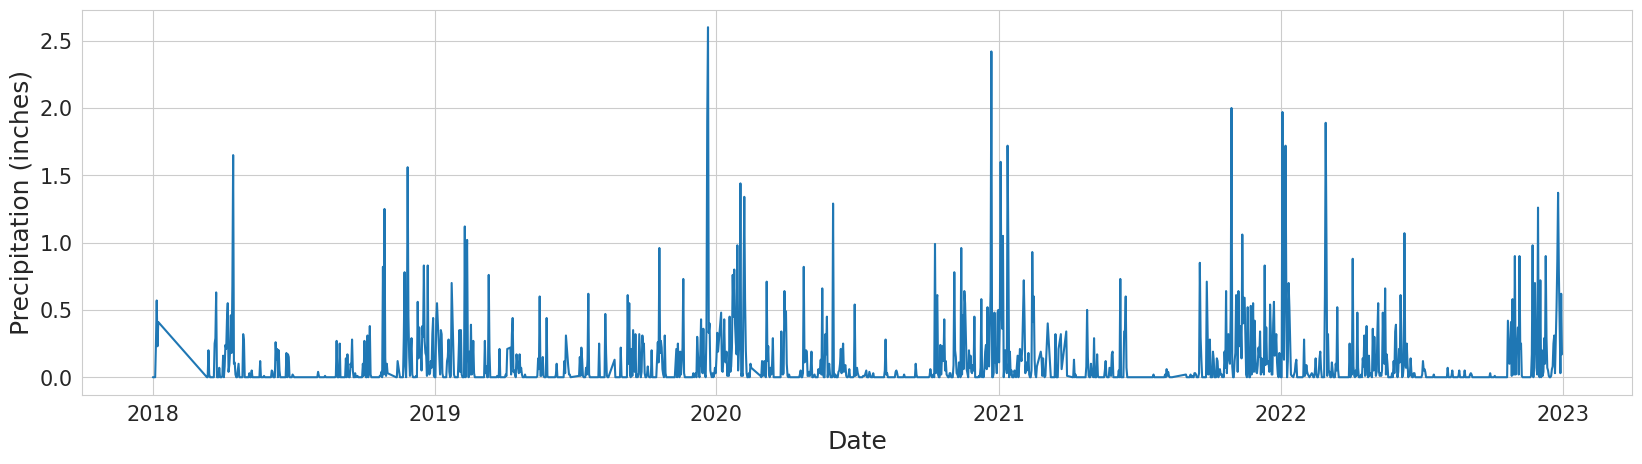

In [22]:
plt.figure(figsize = (20, 5))

sns.lineplot(data = df_seattle, x = 'DATE', y = 'PRCP')

# Label
plt.xlabel('Date', fontsize = 18)
plt.ylabel('Precipitation (inches)', fontsize = 18)

plt.tick_params(labelsize = 15)

plt.show()

**There is a straight line from the first quarter of 2018 -> Missing value**

#### Bekerley dataset

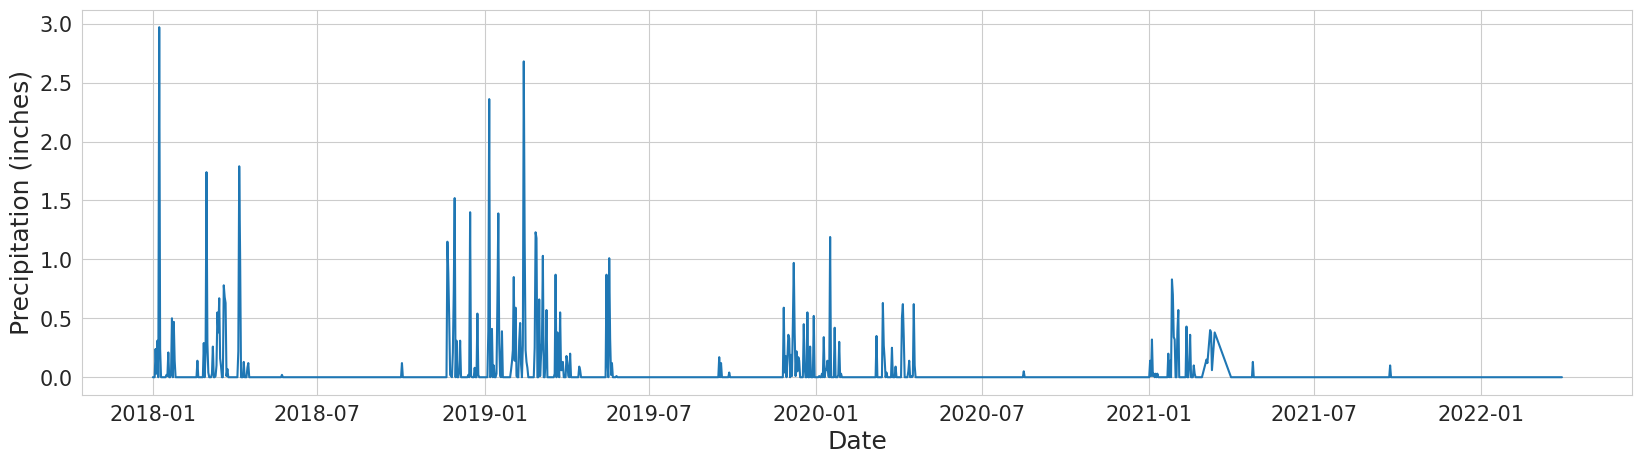

In [23]:
plt.figure(figsize = (20, 5))

sns.lineplot(data = df_berkeley, x = 'DATE', y = 'PRCP')

# Label
plt.xlabel('Date', fontsize = 18)
plt.ylabel('Precipitation (inches)', fontsize = 18)

plt.tick_params(labelsize = 15)

plt.show()

**Berkeley dataset have a lot of missing data that's  why there is some gap. Also berkeley has summer season which does not have rain**

### Join dataframes keeping DATE and PRCP columns

In [24]:
df_seattle.head(2)

,STATION,NAME,DATE,DAPR,MDPR,PRCP,SNOW,SNWD,WESD,WESF
0,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",2018-01-01,NaN,NaN,0.0,NaN,NaN,NaN,NaN
1,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",2018-01-02,NaN,NaN,0.0,NaN,NaN,NaN,NaN


In [25]:
df_berkeley.head(2)

,STATION,NAME,DATE,PRCP
0,USC00040693,"BERKELEY, CA US",2018-01-01,0.0
1,USC00040693,"BERKELEY, CA US",2018-01-02,0.0


#### Use outer join to keep all dates present

In [26]:
df = df_berkeley[['DATE', 'PRCP']].merge(df_seattle[['DATE','PRCP']], on = 'DATE', how = 'outer')

In [27]:
df

,DATE,PRCP_x,PRCP_y
0,2018-01-01,0.00,0.00
1,2018-01-02,0.00,0.00
2,2018-01-03,0.00,0.00
3,2018-01-04,0.24,0.00
4,2018-01-05,0.03,0.25
...,...,...,...
1814,2022-12-27,NaN,0.78
1815,2022-12-28,NaN,0.40
1816,2022-12-29,NaN,0.03
1817,2022-12-30,NaN,0.62


##### How many data points should we have from 2018 to 2022:
365 x 5 + 1 = 1826 days
Rigt here we just have 1819 rows = 1819 days so there is still 7 days missing after join the dataset

### Find and add that 7 days to the dataset

In [28]:
# Create all dates that should exist
complete_dates = pd.DataFrame({
    'DATE': pd.date_range(
        start='2018-01-01',
        end='2022-12-31',
        freq='D'
    )
})

# Merge that all date to the dataset
df = complete_dates.merge(
    df,
    on='DATE',
    how='left'
)

In [29]:
df

,DATE,PRCP_x,PRCP_y
0,2018-01-01,0.00,0.00
1,2018-01-02,0.00,0.00
2,2018-01-03,0.00,0.00
3,2018-01-04,0.24,0.00
4,2018-01-05,0.03,0.25
...,...,...,...
1821,2022-12-27,NaN,0.78
1822,2022-12-28,NaN,0.40
1823,2022-12-29,NaN,0.03
1824,2022-12-30,NaN,0.62


### Create a tidy data frame with columns for city and precipitation

In [30]:
df = pd.melt(df, id_vars = 'DATE', var_name = 'city', value_name = 'precipitation' )

In [31]:
df

,DATE,city,precipitation
0,2018-01-01,PRCP_x,0.00
1,2018-01-02,PRCP_x,0.00
2,2018-01-03,PRCP_x,0.00
3,2018-01-04,PRCP_x,0.24
4,2018-01-05,PRCP_x,0.03
...,...,...,...
3647,2022-12-27,PRCP_y,0.78
3648,2022-12-28,PRCP_y,0.40
3649,2022-12-29,PRCP_y,0.03
3650,2022-12-30,PRCP_y,0.62


### Rename the city values 'BER' and 'SEA'

In [32]:
df.loc[df['city'] == 'PRCP_x', 'city'] = 'BER'
df.loc[df['city'] == 'PRCP_y', 'city'] = 'SEA'

In [33]:
df

,DATE,city,precipitation
0,2018-01-01,BER,0.00
1,2018-01-02,BER,0.00
2,2018-01-03,BER,0.00
3,2018-01-04,BER,0.24
4,2018-01-05,BER,0.03
...,...,...,...
3647,2022-12-27,SEA,0.78
3648,2022-12-28,SEA,0.40
3649,2022-12-29,SEA,0.03
3650,2022-12-30,SEA,0.62


### Rename the column

In [34]:
df = df.rename(columns = {'DATE': 'date'})

In [35]:
df

,date,city,precipitation
0,2018-01-01,BER,0.00
1,2018-01-02,BER,0.00
2,2018-01-03,BER,0.00
3,2018-01-04,BER,0.24
4,2018-01-05,BER,0.03
...,...,...,...
3647,2022-12-27,SEA,0.78
3648,2022-12-28,SEA,0.40
3649,2022-12-29,SEA,0.03
3650,2022-12-30,SEA,0.62


## Handle missing data

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3652 entries, 0 to 3651
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           3652 non-null   datetime64[ns]
 1   city           3652 non-null   object        
 2   precipitation  2991 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 85.7+ KB


In [37]:
# Get number of non missing data
df.notna().sum()

date             3652
city             3652
precipitation    2991
dtype: int64

In [38]:
df.loc[df['city'] == 'BER', 'precipitation'].isna().sum()

471

In [39]:
df.loc[df['city'] == 'SEA', 'precipitation'].isna().sum()

190

### How many data points should we have from 2018 to 2022:
365 x 5 + 1 = 1826 days

In [40]:
# Define a column that labels each day by day of the year: 1, 2, 3,... 365
df['day_of_year'] = pd.DatetimeIndex(df['date']).day_of_year

In [41]:
df.head()

,date,city,precipitation,day_of_year
0,2018-01-01,BER,0.00,1
1,2018-01-02,BER,0.00,2
2,2018-01-03,BER,0.00,3
3,2018-01-04,BER,0.24,4
4,2018-01-05,BER,0.03,5


I would like to use mean precipitaion for each day average across year to fill the missing value but the worst scenario is all day of 5 years is missing so I would like to check it first. Escpecially, Berkeley has over 25% missing data (471 days).

## Handle Berkeley missing data

In [42]:
# Get all missing date of Berkeley
df_missing_berkeley = df[(df['precipitation'].isna() == True) & (df['city'] == "BER")]
df_missing_berkeley

,date,city,precipitation,day_of_year
638,2019-10-01,BER,NaN,274
639,2019-10-02,BER,NaN,275
640,2019-10-03,BER,NaN,276
641,2019-10-04,BER,NaN,277
642,2019-10-05,BER,NaN,278
...,...,...,...,...
1821,2022-12-27,BER,NaN,361
1822,2022-12-28,BER,NaN,362
1823,2022-12-29,BER,NaN,363
1824,2022-12-30,BER,NaN,364


### Count missing day follow by day_of_year

In [43]:
berkeley_day_count_missing = df_missing_berkeley.groupby('day_of_year').size().reset_index(name = 'missing_count')
berkeley_day_count_missing

,day_of_year,missing_count
0,60,1
1,61,1
2,62,1
3,63,1
4,66,1
...,...,...
296,362,2
297,363,2
298,364,2
299,365,2


### How many day_of_year have 3 and 4 missing day?


In [44]:
berkeley_day_count_missing[(berkeley_day_count_missing['missing_count'].isin([3,4]))] 

,day_of_year,missing_count
208,274,3
209,275,4
210,276,4
211,277,4
212,278,4
213,279,4
214,280,4
215,281,4
216,282,4
217,283,4


**From day 274 to day 319, there are 45 consecutive days with 3 to 4 missing values across the 5-year period, which can produce unreliable mean precipitation estimates for those days.**

### Better solution to handle Berkeley missing data

Historical Berkeley precipitation data were divided into training and testing periods. Data from 1998 through 2013 were used to train the ARIMA model, while data from 2014 through 2017 were used to evaluate the model using one-day-ahead walk-forward prediction. After each prediction, the actual observed value was added to the model before predicting the next day. Model performance was evaluated using MAE, RMSE, and an actual-versus-predicted plot. After evaluation, the ARIMA model was retrained using all available data from 1998 through 2017. The final model was then applied to the 2018–2022 period using the same walk-forward approach. Observed precipitation values were kept unchanged, while ARIMA predictions were used only to replace missing values.

In [45]:
# import ARIMA model from sklearn
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

### Load the berkeley training dataset

In [46]:
berkeley_25 = pd.read_csv("../data/berkeley_25_years.csv")

In [47]:
berkeley_25.head()

,STATION,NAME,DATE,DAPR,MDPR,PRCP,SNOW,SNWD
0,USC00040693,"BERKELEY, CA US",1998-01-01,NaN,NaN,0.00,0.0,0.0
1,USC00040693,"BERKELEY, CA US",1998-01-02,NaN,NaN,0.00,0.0,0.0
2,USC00040693,"BERKELEY, CA US",1998-01-03,NaN,NaN,0.00,0.0,0.0
3,USC00040693,"BERKELEY, CA US",1998-01-04,NaN,NaN,0.00,0.0,0.0
4,USC00040693,"BERKELEY, CA US",1998-01-05,NaN,NaN,1.85,0.0,0.0


### Clean the Berkeley 25 years data

In [48]:
# select only DATE, PRCP and rename
berkeley_25 = berkeley_25[['DATE', 'PRCP']].rename(columns={'DATE':'date', 'PRCP':'precipitation'})

In [49]:
# Convert date to dataframe
berkeley_25['date'] = pd.to_datetime(berkeley_25['date'])

In [50]:
# Set date as index
berkeley_25 = berkeley_25.set_index('date').sort_index()

In [51]:
# Make sure every calendar day exist
berkeley_25 = berkeley_25.asfreq('D')

In [52]:
berkeley_25

,precipitation
date,
1998-01-01,0.00
1998-01-02,0.00
1998-01-03,0.00
1998-01-04,0.00
1998-01-05,1.85
...,...
2022-12-27,NaN
2022-12-28,NaN
2022-12-29,NaN


In [53]:
berkeley_25.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9131 entries, 1998-01-01 to 2022-12-31
Freq: D
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   precipitation  8278 non-null   float64
dtypes: float64(1)
memory usage: 142.7 KB


In [54]:
berkeley_25['precipitation'].isna().sum()

853

The Berkeley dataset contains 9,131 daily observations, of which 853 precipitation values are missing. Since the missing values represent a relatively small proportion of the full dataset, the missing observations are retained as NaN values rather than removed. The ARIMA model can be fitted using the available observations while preserving the continuous daily time index.

### Split the Berkeley 25 years data to training, testing, and target dataset

In [55]:
# training dataset from 1998 to 2013
train = berkeley_25.loc['1998-01-01':'2013-12-31'].copy()

In [56]:
# testing dataset from 2014 to 2017
test = berkeley_25.loc['2014-01-01':'2017-12-31'].copy()

In [57]:
# target (predict) dataset from 2018 to 2022
target = berkeley_25.loc['2018-01-01':'2022-12-31'].copy()

In [58]:
# Check size
print("Train", train.shape)
print("Test", test.shape)
print("Target", target.shape)

Train (5844, 1)
Test (1461, 1)
Target (1826, 1)


#### Train the data with ARIMA model

In [59]:
model = ARIMA(train['precipitation'], order = (2, 0, 1))
model_fit = model.fit()

/home/phuc/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/phuc/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


### Walk-Forward Prediction

Use the trained ARIMA model to predict one day ahead, then update the model with the actual observation before predicting the next day.

In [60]:
predictions = []
current_model = model_fit

for date in test.index:
    
    # 1. Predict
    prediction = current_model.forecast(steps = 1).iloc[0]

    # 2. Save the prediction
    prediction = max(0, float(prediction)) # the precipitation prediction must >= 0
    predictions.append(prediction)

    # 3. Get actual value
    actual = test.loc[date, 'precipitation']

    # Store today's actual precipitation
    today_index = pd.date_range(start = date, periods = 1, freq='D')
    actual_today = pd.Series([actual], index = today_index, name='precipitation')

    # 4. Up date model
    current_model = current_model.extend(actual_today)
    

### Transfrom test prediction to data set

In [61]:
test_prediction = pd.Series(predictions, index=test.index)

### Compare predictions with the actual test data

In [62]:
# Evaluate onlu the dates where we actually know the precipitation
test_observed = test['precipitation'].notna()

### Calculate MAE

In [63]:
mae = mean_absolute_error(
    test.loc[test_observed, 'precipitation'],
    test_prediction.loc[test_observed]
)

print(f"MAE: {mae:.4f} inches")

MAE: 0.1091 inches


### Calculate RMSE

In [64]:
rmse = np.sqrt(
    mean_squared_error(
        test.loc[test_observed, 'precipitation'],
        test_prediction.loc[test_observed]
    )
)

print(f"RMSE: {rmse:.4f} inches")

RMSE: 0.2750 inches


In [65]:
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:          precipitation   No. Observations:                 5844
Model:                 ARIMA(2, 0, 1)   Log Likelihood                  19.122
Date:                Tue, 06 Oct 2026   AIC                            -28.244
Time:                        17:23:47   BIC                              5.122
Sample:                    01-01-1998   HQIC                           -16.642
                         - 12-31-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0784      0.021      3.665      0.000       0.036       0.120
ar.L1          1.1336      0.012     97.994      0.000       1.111       1.156
ar.L2         -0.1607      0.008    -19.918      0.0

### Explaination:

The ARIMA(2,0,1) model shows statistically significant AR and MA coefficients, indicating that recent precipitation values and previous prediction errors help explain short-term precipitation patterns. However, the residuals are highly skewed and non-normal, which is expected because precipitation contains many zero values and occasional large rainfall events. In the walk-forward test from 2014 to 2017, the model achieved an MAE of about 0.109 inches and an RMSE of about 0.275 inches. 

Overall, the model captures short-term precipitation patterns reasonably well, but it has difficulty predicting extreme rainfall events.

### Plot compare Actual and Predicted

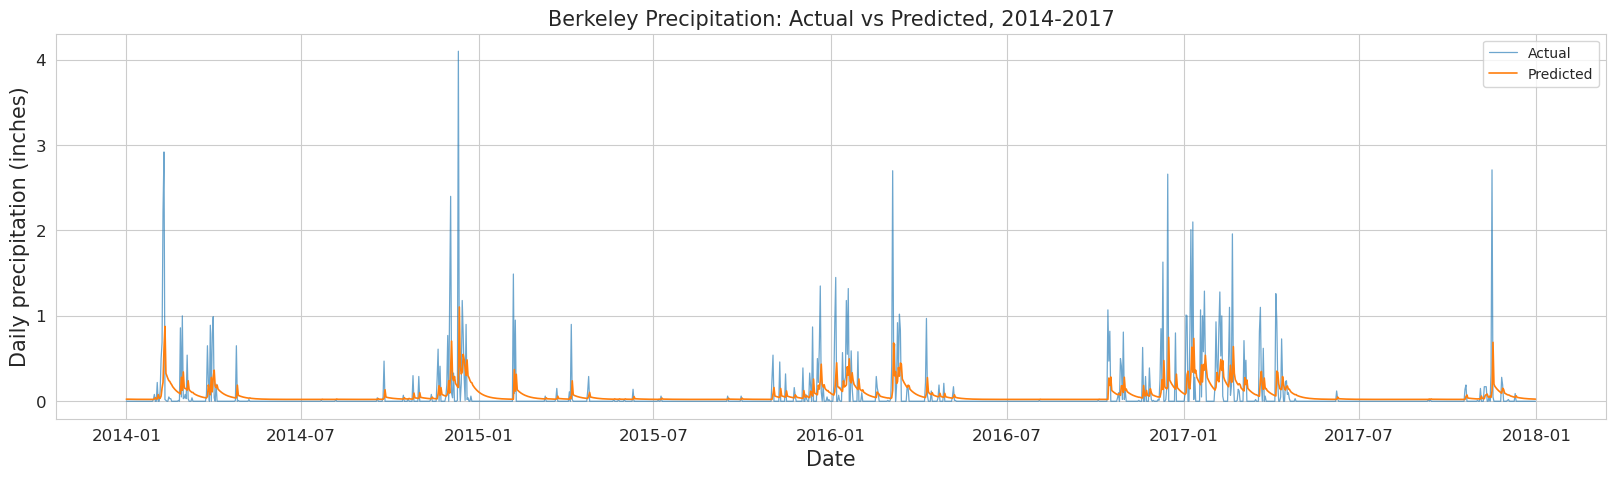

In [66]:
plt.figure(figsize=(20, 5))

# Actual precipitation
plt.plot(test.index, test['precipitation'], label='Actual', alpha=0.65, linewidth=0.9)

# Predicted precipitation
plt.plot(test_prediction.index, test_prediction, label='Predicted', linewidth=1.2)

plt.xlabel('Date', fontsize=15)
plt.ylabel('Daily precipitation (inches)', fontsize=15)
plt.title('Berkeley Precipitation: Actual vs Predicted, 2014-2017', fontsize=15)

plt.tick_params(labelsize=12)
plt.legend()

plt.show()

### Explain

Although the model tends to underestimate large precipitation events, it provides reasonable short-term estimates and will therefore be used to estimate the missing Berkeley precipitation values

## Retrain the final model using 1998–2017

In [67]:
final_train = berkeley_25.loc['1998-01-01':'2017-12-31'].copy()

final_model = ARIMA(final_train['precipitation'], order=(2, 0, 1))

final_model_fit = final_model.fit()

/home/phuc/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/phuc/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


### Train and fit final model

In [68]:
final_model = ARIMA(final_train['precipitation'], order=(2, 0, 1))
final_model_fit = final_model.fit()

/home/phuc/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/phuc/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


### Create imputed columns

In [69]:
target['precipitation_ARIMA_imputed'] = target['precipitation']

In [70]:
current_model = final_model_fit

for date in target.index:
    
    # 1. Predict
    prediction = current_model.forecast(steps = 1).iloc[0]

    prediction = max(0, float(prediction)) # the precipitation prediction must >= 0

    # 2. Get actual value
    actual = target.loc[date, 'precipitation']

    # 3.If precipitation is missing, use prediction
    if pd.isna(actual):
        target.loc[date, 'precipitation_ARIMA_imputed'] = prediction

    # Store today's actual precipitation
    today_index = pd.date_range(start = date, periods = 1, freq='D')
    actual_today = pd.Series([actual], index = today_index, name='precipitation')

    # 4. Up date model
    current_model = current_model.extend(actual_today)
    

### Check the result

In [71]:
target['precipitation'].isna().sum()

471

In [72]:
target['precipitation_ARIMA_imputed'].isna().sum()

0

In [73]:
target.loc[target['precipitation'].isna(), ['precipitation', 'precipitation_ARIMA_imputed']]

,precipitation,precipitation_ARIMA_imputed
date,,
2019-10-01,NaN,0.027136
2019-10-02,NaN,0.033040
2019-10-03,NaN,0.035206
2019-10-04,NaN,0.036685
2019-10-05,NaN,0.038009
...,...,...
2022-12-27,NaN,0.077435
2022-12-28,NaN,0.077435
2022-12-29,NaN,0.077436


In [74]:
target

,precipitation,precipitation_ARIMA_imputed
date,,
2018-01-01,0.00,0.000000
2018-01-02,0.00,0.000000
2018-01-03,0.00,0.000000
2018-01-04,0.24,0.240000
2018-01-05,0.03,0.030000
...,...,...
2022-12-27,NaN,0.077435
2022-12-28,NaN,0.077435
2022-12-29,NaN,0.077436


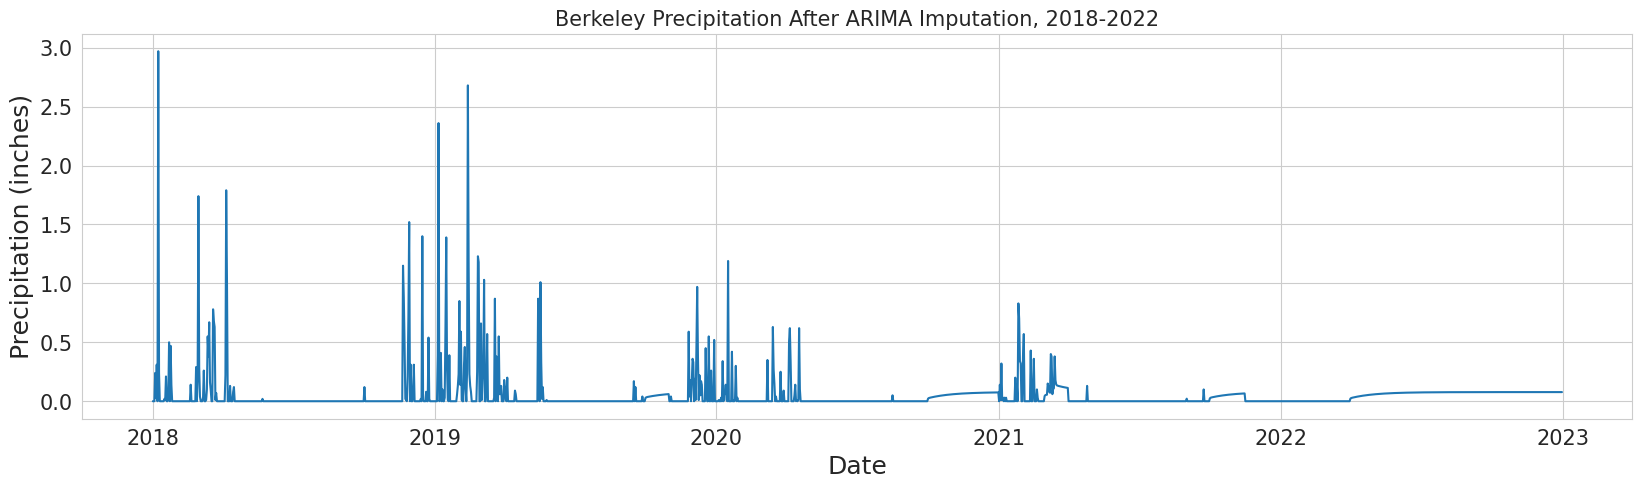

In [75]:
plt.figure(figsize = (20, 5))

sns.lineplot(data = target, x = 'date', y = 'precipitation_ARIMA_imputed')

# Label
plt.xlabel('Date', fontsize = 18)
plt.ylabel('Precipitation (inches)', fontsize = 18)
plt.title('Berkeley Precipitation After ARIMA Imputation, 2018-2022', fontsize=15)

plt.tick_params(labelsize = 15)

plt.show()

### Conclusion

The ARIMA model did not perform well for this dataset because long periods of consecutive missing values caused the predictions to become nearly constant and fail to follow Berkeley’s seasonal precipitation pattern. Therefore, I decided to use a K-Nearest Neighbors (KNN) regression model instead. Berkeley precipitation follows a relatively consistent annual cycle, with very low precipitation during the summer and higher precipitation during the cooler months. Using approximately 20 years of historical data allows the KNN model to learn precipitation patterns from similar times of the year and use them to estimate the missing values from 2018 through 2022. All valid historical precipitation observations, including large rainfall events, are retained for model training.

### K-Nearest Neighbors (KNN) Model

The ARIMA model did not perform well for this dataset because long periods of consecutive missing values caused the predictions to become nearly constant and fail to follow Berkeley's seasonal precipitation pattern. Therefore, a K-Nearest Neighbors (KNN) regression model was used instead.

Berkeley precipitation follows a relatively consistent annual cycle, with very low precipitation during the summer and higher precipitation during the cooler months. Using historical Berkeley precipitation data from 1998 through 2017 allows the KNN model to learn precipitation patterns from similar times of the year and use them to estimate missing values from 2018 through 2022.

The KNN model was first evaluated on a test period from 2014 through 2017. After evaluation, it was retrained using all available historical data from 1998 through 2017 and then used to impute missing Berkeley precipitation values for 2018 through 2022.

## Import the KNN model

In [76]:
from sklearn.neighbors import KNeighborsRegressor

### Create features

KNN requires numerical features that describe how similar two dates are. Because precipitation follows an annual cycle, sine and cosine transformations of the day of year are used so that dates near the end and beginning of the year are treated as seasonally close.

In [77]:
# Create cyclical seasonal features
def make_features(data):

    X = pd.DataFrame(index=data.index)

    day_of_year = data.index.dayofyear.to_numpy()

    X['sin1'] = np.sin(2 * np.pi * day_of_year / 365.25)
    X['cos1'] = np.cos(2 * np.pi * day_of_year / 365.25)

    X['sin2'] = np.sin(4 * np.pi * day_of_year / 365.25)
    X['cos2'] = np.cos(4 * np.pi * day_of_year / 365.25)

    return X

### Train/test split

In [78]:
# Training dataset from 1998 to 2013
train = berkeley_25.loc['1998-01-01':'2013-12-31'].copy()

# Testing dataset from 2014 to 2017
test = berkeley_25.loc['2014-01-01':'2017-12-31'].copy()

# Target dataset from 2018 to 2022
target = berkeley_25.loc['2018-01-01':'2022-12-31'].copy()

# Create features
train_features = make_features(train)
test_features = make_features(test)

# Keep observed precipitation values only
train_observed = train['precipitation'].notna()

### Fit the KNN model

In [79]:
model = KNeighborsRegressor(n_neighbors=20, weights='distance')

model_fit = model.fit(train_features.loc[train_observed], train.loc[train_observed, 'precipitation'])

Twenty neighbors were used so that each prediction is based on multiple historical observations from similar times of the year. Distance weighting gives greater influence to the most seasonally similar dates.

### Predict test period

In [80]:
predictions = model_fit.predict(test_features)

# Precipitation cannot be negative
predictions = np.maximum(0, predictions)

test_prediction = pd.Series(predictions, index=test.index)

### Evaluate KNN

In [81]:
test_observed = test['precipitation'].notna()

mae = mean_absolute_error(
    test.loc[test_observed, 'precipitation'],
    test_prediction.loc[test_observed]
)

rmse = np.sqrt(
    mean_squared_error(
        test.loc[test_observed, 'precipitation'],
        test_prediction.loc[test_observed]
    )
)

print(f'MAE: {mae:.4f} inches')
print(f'RMSE: {rmse:.4f} inches')

MAE: 0.1171 inches
RMSE: 0.2915 inches


Although the KNN model has slightly higher MAE and RMSE than ARIMA on the 2014–2017 test period, KNN better preserves Berkeley's annual seasonal precipitation pattern during long missing periods. ARIMA relies strongly on recent observations and tends toward nearly constant predictions when many consecutive observations are missing. Since the main purpose of the model is to impute long missing blocks rather than perform short-term weather forecasting, KNN was selected for the final imputation.

### Plot actual vs predicted

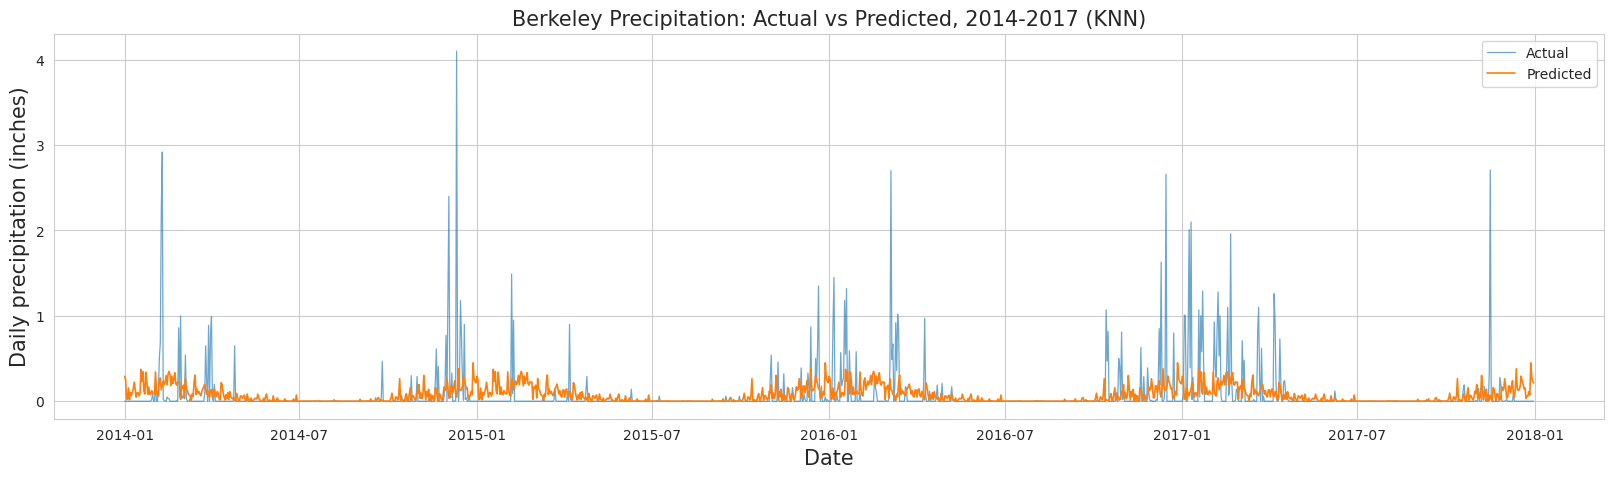

In [82]:
plt.figure(figsize=(20, 5))

plt.plot(
    test.index,
    test['precipitation'],
    label='Actual',
    alpha=0.65,
    linewidth=0.9
)

plt.plot(
    test_prediction.index,
    test_prediction,
    label='Predicted',
    linewidth=1.2
)

plt.xlabel('Date', fontsize=15)
plt.ylabel('Daily precipitation (inches)', fontsize=15)
plt.title('Berkeley Precipitation: Actual vs Predicted, 2014-2017 (KNN)', fontsize=15)

plt.legend()
plt.show()

The KNN model follows Berkeley's seasonal precipitation pattern more closely than the ARIMA model. In particular, it preserves the dry summer pattern and avoids the nearly constant predictions produced by ARIMA during long missing periods. Because Berkeley precipitation is strongly seasonal, KNN is better suited for estimating missing values using similar days from historical years.

## Final KNN model for imputation

In [83]:
# Final training data from 1998 to 2017
final_train = berkeley_25.loc['1998-01-01':'2017-12-31'].copy()

# Create features
final_train_features = make_features(final_train)
target_features = make_features(target)

# Keep observed values only
final_observed = final_train['precipitation'].notna()

final_model = KNeighborsRegressor(n_neighbors=20, weights='distance')

final_model_fit = final_model.fit(final_train_features.loc[final_observed], final_train.loc[final_observed, 'precipitation'])

### Impute missing value

In [84]:
# Predict 2018-2022 precipitation
target_prediction = pd.Series(final_model_fit.predict(target_features), index=target.index)

# Precipitation cannot be negative
target_prediction = target_prediction.clip(lower=0)

# Keep original values
target['precipitation_imputed'] = target['precipitation'].copy()

# Replace only missing values
missing = target['precipitation'].isna()

target.loc[missing, 'precipitation_imputed'] = target_prediction.loc[missing]

### Check result

In [85]:
print('Missing before:', target['precipitation'].isna().sum())
print('Missing after:', target['precipitation_imputed'].isna().sum())

Missing before: 471
Missing after: 0


### Plot KNN imputed data

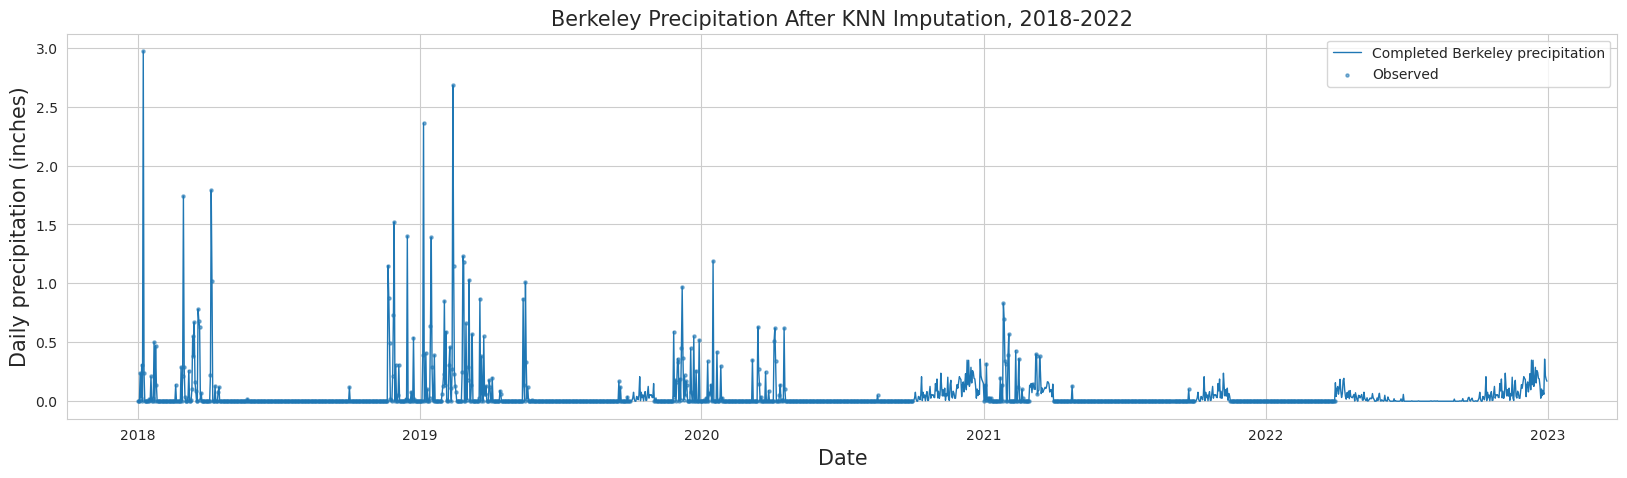

In [86]:
plt.figure(figsize=(20, 5))

plt.plot(
    target.index,
    target['precipitation_imputed'],
    label='Completed Berkeley precipitation',
    linewidth=1.0
)

plt.scatter(
    target.index[target['precipitation'].notna()],
    target.loc[target['precipitation'].notna(), 'precipitation'],
    label='Observed',
    s=5,
    alpha=0.55
)

plt.xlabel('Date', fontsize=15)
plt.ylabel('Daily precipitation (inches)', fontsize=15)
plt.title('Berkeley Precipitation After KNN Imputation, 2018-2022', fontsize=15)

plt.legend()
plt.show()

## Impute Berkeley missing values

ARIMA was first evaluated as a possible imputation method. Although it performed reasonably for one-day-ahead prediction, it produced nearly constant predictions during long periods of consecutive missing data. Therefore, KNN was evaluated as an alternative and selected for the final Berkeley imputation.

In [87]:
# Find Berkeley rows with missing precipitation
berkeley_missing = ((df['city'] == 'BER') & (df['precipitation'].isna()))
# Replace only Berkeley's missing values
df.loc[berkeley_missing, 'precipitation'] = (df.loc[berkeley_missing, 'date'].map(target['precipitation_imputed']))

In [88]:
df.loc[df['city'] == 'BER', 'precipitation'].isna().sum()

0

### Impute Seattle missing values
I will replace missing values with the mean across years of values on that day.

**Design an algorithm for replacing missing values with the mean across years of values on that day**

In [89]:
# Compute the mean precipitation for each day in _, average across year
def mean_day_precipitation(location):
    mean_day_precipitation = df.loc[
        df['city'] == location,
        ['precipitation', 'day_of_year']
    ].groupby('day_of_year').mean()
    return mean_day_precipitation

In [90]:
# mean precipitation in Seatlle, average across year
mean_day_precipitation_seattle = mean_day_precipitation('SEA')
mean_day_precipitation_seattle

,precipitation
day_of_year,
1,0.052000
2,0.150000
3,0.836000
4,0.370000
5,0.246667
...,...
362,0.120000
363,0.102000
364,0.268000


In [91]:
# Check if there is missing value in average across year
mean_day_precipitation_seattle['precipitation'].isna().sum()

0

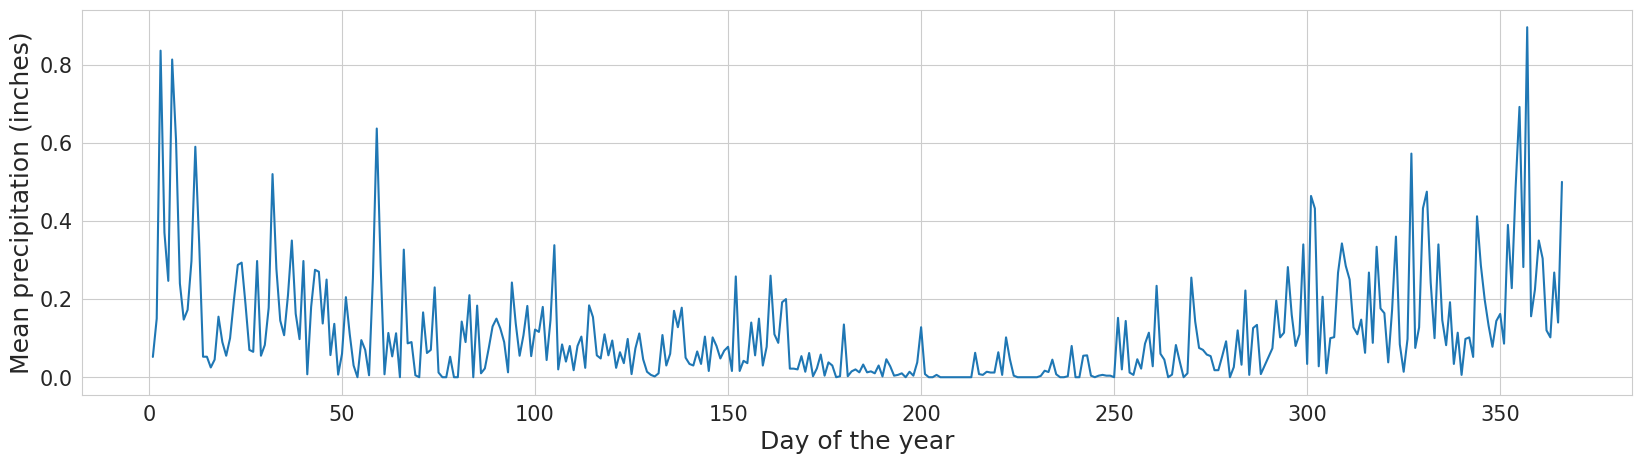

In [92]:
plt.figure(figsize =(20,5))

sns.lineplot(data = mean_day_precipitation('SEA'), x = 'day_of_year', y = 'precipitation')

plt.xlabel('Day of the year', fontsize = 18)
plt.ylabel('Mean precipitation (inches)', fontsize = 18)

plt.tick_params(labelsize = 15)
plt.show()

Over the five-year period, Seattle show a clear seasonal precipitaition pattern. Mean daily precipitation is highest in the winter, with peak close to 0.9 inches, while summer precipitation is much lower, generally staying below 0.15 inches. This suggests that Seattle is much wetter in the winter and receives relatively low precipitation during the summer

### Replace Seattle missing value with average across year

In [93]:
# Find missing index of seattle precipitation
indices_seattle = np.where((df['precipitation'].isna() == True) & (df['city'] == 'SEA'))[0]
indices_seattle

array([1834, 1835, 1836, 1837, 1838, 1839, 1840, 1841, 1842, 1843, 1844,
       1845, 1846, 1847, 1848, 1849, 1850, 1851, 1852, 1853, 1854, 1855,
       1856, 1857, 1858, 1859, 1860, 1861, 1862, 1863, 1864, 1865, 1866,
       1867, 1868, 1869, 1870, 1871, 1872, 1873, 1874, 1875, 1876, 1877,
       1878, 1879, 1880, 1881, 1882, 1883, 1884, 1885, 1886, 1887, 1888,
       1889, 1890, 1891, 1892, 1893, 1894, 1895, 2090, 2131, 2132, 2133,
       2134, 2135, 2136, 2137, 2138, 2139, 2140, 2195, 2196, 2197, 2214,
       2215, 2244, 2245, 2246, 2247, 2248, 2249, 2286, 2287, 2288, 2362,
       2363, 2368, 2369, 2370, 2371, 2372, 2373, 2374, 2375, 2376, 2377,
       2417, 2418, 2419, 2420, 2421, 2422, 2423, 2517, 2518, 2519, 2520,
       2521, 2522, 2523, 2524, 2559, 2560, 2561, 2602, 2603, 2604, 2605,
       2606, 2607, 2608, 2609, 2610, 2611, 2612, 2818, 2819, 2820, 2821,
       2822, 2823, 2824, 2825, 2826, 2827, 2972, 2973, 2974, 2975, 2983,
       2984, 2986, 2987, 2988, 3000, 3001, 3004, 30

In [94]:
# Replace Seattle's missing value with average across year 
for index in indices_seattle:
    df.loc[index, 'precipitation'] = mean_day_precipitation_seattle.loc[df.loc[index, 'day_of_year']].values[0]

In [95]:
# Double check again
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3652 entries, 0 to 3651
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           3652 non-null   datetime64[ns]
 1   city           3652 non-null   object        
 2   precipitation  3652 non-null   float64       
 3   day_of_year    3652 non-null   int32         
dtypes: datetime64[ns](1), float64(1), int32(1), object(1)
memory usage: 100.0+ KB


### => No more missing value

## Export the clean .csv file

In [96]:
df.to_csv('clean_seattle_berkeley_weather.csv', encoding='utf-8-sig', index=False)

## Exploratory data analysis

Plot the daily precipitation for both cities on the same graph

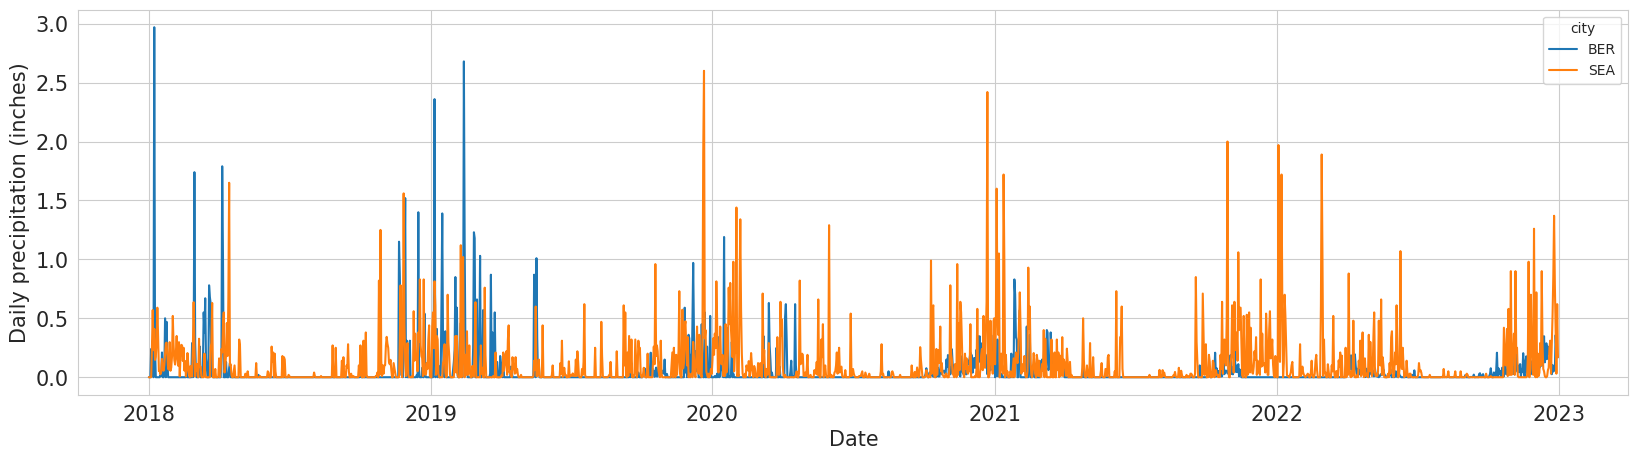

In [97]:
plt.figure(figsize = (20,5))

sns.lineplot(data = df, x = 'date', y = 'precipitation', hue = 'city')

plt.xlabel('Date', fontsize = 15)
plt.ylabel('Daily precipitation (inches)', fontsize = 15)

plt.tick_params(labelsize = 15)

plt.show()

Berkeley shows several larger precipitation events in 2018 and 2019. However, from 2020 through 2022, Seattle generally experiences more frequent and higher precipitation events than Berkeley. Overall, the graph suggests that Seattle is wetter across most of the five-year period.

#### Compute basic numerical summaries for precipitation in each city

In [98]:
df[['city', 'precipitation']].groupby('city').describe()

precipitation                                                   
             count     mean       std  min  25%   50%       75%   max
city                                                                 
BER         1826.0  0.05305  0.185588  0.0  0.0  0.00  0.021388  2.97
SEA         1826.0  0.11327  0.240516  0.0  0.0  0.01  0.120000  2.60

Compare mean precipitation values averaged over all days

In [99]:
df[['city', 'precipitation']].groupby('city').mean()

,precipitation
city,
BER,0.05305
SEA,0.11327


Show the values as a bar graph

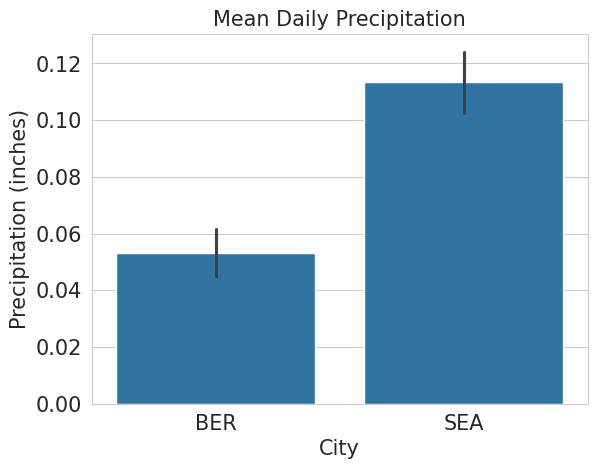

In [100]:
sns.barplot(data = df, x = 'city', y = 'precipitation')

plt.ylabel('Precipitation (inches)', fontsize = 15)
plt.xlabel('City', fontsize = 15)
plt.title('Mean Daily Precipitation', fontsize = 15)

plt.tick_params(labelsize = 15)

plt.show()

Seattle has a higher average daily precipitation than Berkeley, averaging approximately 0.113 inches per day compared with 0.053 inches per day in Berkeley.

#### Precipitation by month

Add a column to the data frame with the number of the month

In [101]:
df['month'] = pd.DatetimeIndex(df['date']).month

In [102]:
df.head()

,date,city,precipitation,day_of_year,month
0,2018-01-01,BER,0.00,1,1
1,2018-01-02,BER,0.00,2,1
2,2018-01-03,BER,0.00,3,1
3,2018-01-04,BER,0.24,4,1
4,2018-01-05,BER,0.03,5,1


In [103]:
df['month'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12], dtype=int32)

Plot the distribution of precipitation amounts each month using boxplot

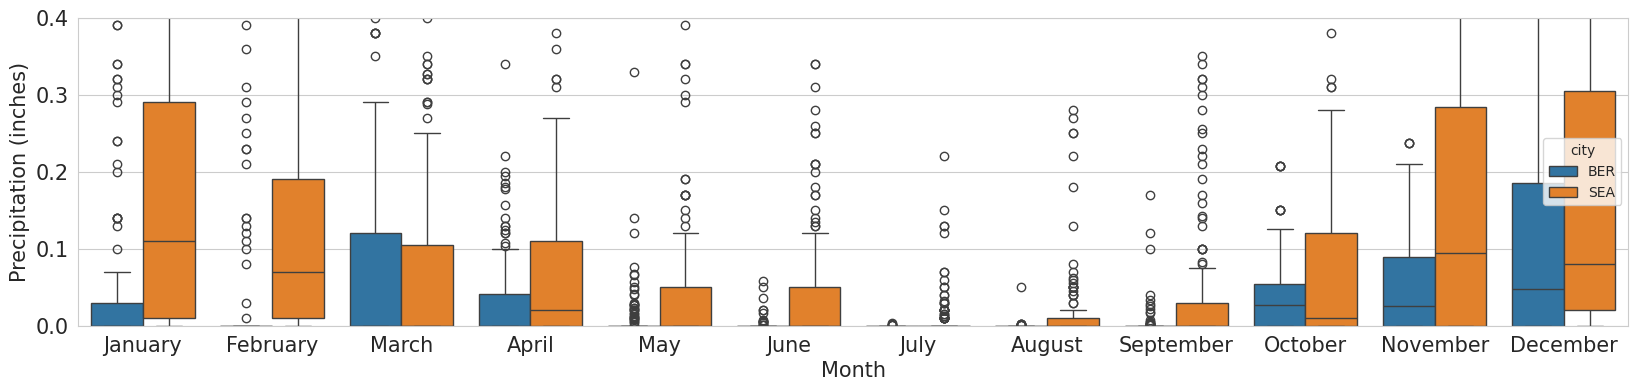

In [104]:
plt.figure(figsize = (20,4))

sns.boxplot(data = df, x = 'month', y = 'precipitation', hue = 'city')

plt.xlabel('Month', fontsize = 15)
plt.ylabel('Precipitation (inches)', fontsize = 15)

plt.tick_params(labelsize = 15)

# Get month names and set as x-axis tick labels
import calendar
month_names = list(calendar.month_name[1:]) # Get month names
plt.xticks(ticks=range(12), labels = month_names) # Set x-axis ticks to month names

plt.ylim(0, 0.4) # Zoom in

plt.show()

Orient the plot horizontally

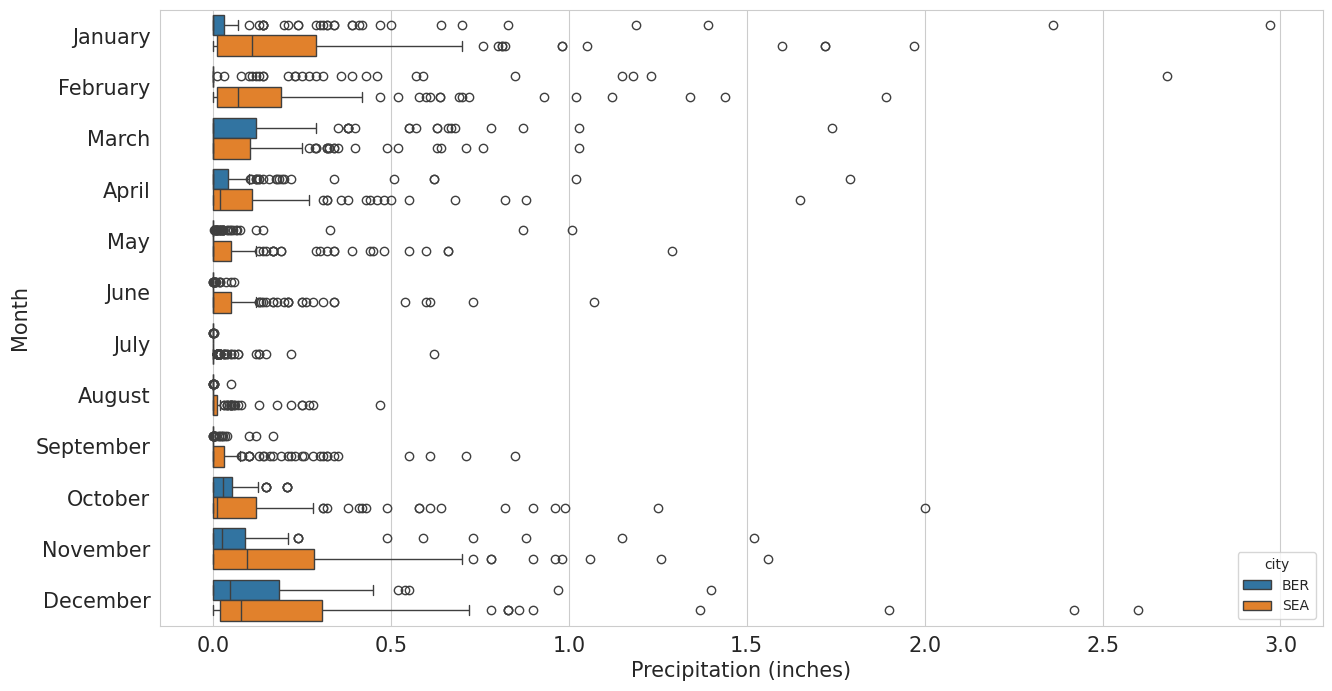

In [105]:
plt.figure(figsize = (15, 8))

sns.boxplot(data = df, x = 'precipitation', y = 'month', hue = 'city', orient = 'h')

plt.ylabel('Month', fontsize = 15)
plt.xlabel('Precipitation (inches)', fontsize = 15)

plt.tick_params(labelsize = 15)

plt.yticks(ticks = range(12), labels = month_names)

plt.show()

#### Plot the mean precipitation each month

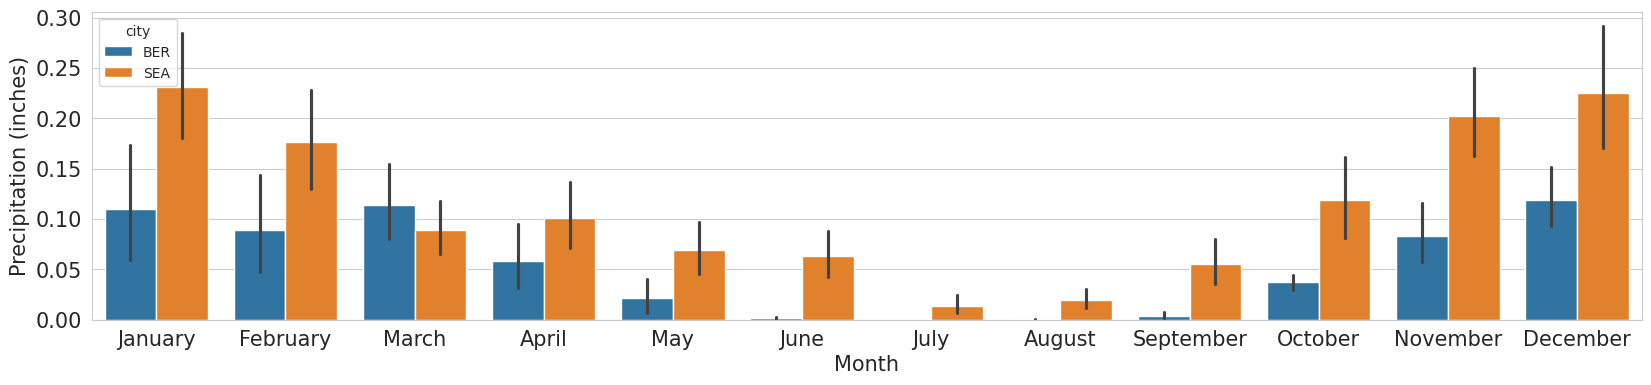

In [106]:
plt.figure(figsize = (20,4))

sns.barplot(data = df, x = 'month', y = 'precipitation', hue = 'city')

plt.xlabel('Month', fontsize = 15)
plt.ylabel('Precipitation (inches)', fontsize = 15)

plt.tick_params(labelsize = 15)

plt.xticks(ticks=range(12), labels = month_names) # Set x-axis ticks to month names

plt.show()

Seattle generally has greater mean daily precipitation than Berkley. The largest different occur during the fall and winter month. Berkley has very littel precipitation during the summer, while Seattle continue receive some precipition.

#### Compute the mean precipitation each month

In [107]:
df[['month', 'precipitation', 'city']].groupby([ 'month','city']).mean()

precipitation
month city               
1     BER        0.110323
      SEA        0.230742
2     BER        0.088936
      SEA        0.176472
3     BER        0.113995
      SEA        0.089075
4     BER        0.057814
      SEA        0.100483
5     BER        0.021134
      SEA        0.069161
6     BER        0.001598
      SEA        0.063167
7     BER        0.000052
      SEA        0.013984
8     BER        0.000411
      SEA        0.019995
9     BER        0.004036
      SEA        0.055622
10    BER        0.037017
      SEA        0.118452
11    BER        0.083316
      SEA        0.201867
12    BER        0.119094
      SEA        0.224903

Plot the proportion of days with any precipitation

In [108]:
df['any_precipitation'] = df['precipitation'] > 0

In [109]:
df.head()

,date,city,precipitation,day_of_year,month,any_precipitation
0,2018-01-01,BER,0.00,1,1,False
1,2018-01-02,BER,0.00,2,1,False
2,2018-01-03,BER,0.00,3,1,False
3,2018-01-04,BER,0.24,4,1,True
4,2018-01-05,BER,0.03,5,1,True


#### Plot the proportion of days with any precipitation over the 5 years

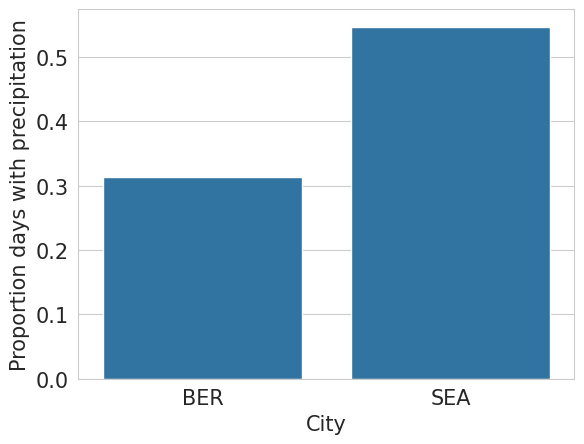

In [110]:
sns.barplot(data = df, x= 'city', y = 'any_precipitation', errorbar = None)

plt.xlabel('City', fontsize = 15)
plt.ylabel('Proportion days with precipitation', fontsize = 15)

plt.tick_params(labelsize = 15)

plt.show()

#### Plot the proportion of days with precipitation each month

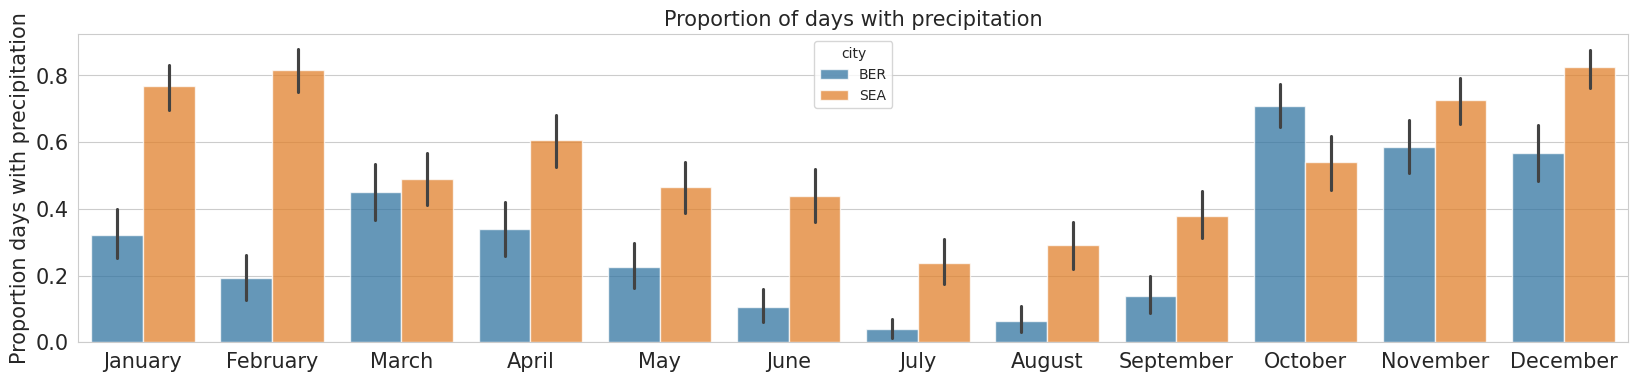

In [111]:
plt.figure(figsize =(20,4))

sns.barplot(data = df, x = 'month', y = 'any_precipitation', hue = 'city', alpha = 0.75)

plt.xlabel(None)
plt.ylabel('Proportion days with precipitation', fontsize = 15)
plt.title('Proportion of days with precipitation', fontsize = 15)

plt.xticks(ticks = range(12), labels = month_names)
plt.tick_params(labelsize = 15)

plt.show()

The proportion of rainy days in March is quite similar, but it is very different in June and July because there is almost no rain in Berkeley during those months.

#### Precipitation by season

In [112]:
# Function to seperate season by month
def get_season(month):
    if month in [3, 4, 5]:
        return 'spring'
    elif month in [6, 7, 8]:
        return 'summer'
    elif month in [9, 10, 11]:
        return 'fall'
    else:
        return 'winter'

In [113]:
df['season'] = df['month'].apply(get_season)

In [114]:
df['year'] = df['date'].dt.year

In [115]:
df.head()

,date,city,precipitation,day_of_year,month,any_precipitation,season,year
0,2018-01-01,BER,0.00,1,1,False,winter,2018
1,2018-01-02,BER,0.00,2,1,False,winter,2018
2,2018-01-03,BER,0.00,3,1,False,winter,2018
3,2018-01-04,BER,0.24,4,1,True,winter,2018
4,2018-01-05,BER,0.03,5,1,True,winter,2018


### Computer sum precipitation by season each year

In [116]:
df_season = df.groupby(['year','season','city'])['precipitation'].sum()
df_season = df_season.reset_index()
df_season

,year,season,city,precipitation
0,2018,fall,BER,5.130000
1,2018,fall,SEA,10.271667
2,2018,spring,BER,9.870000
3,2018,spring,SEA,8.692500
4,2018,summer,BER,0.000000
5,2018,summer,SEA,2.060000
6,2018,winter,BER,8.550000
7,2018,winter,SEA,16.220000
8,2019,fall,BER,2.710553
9,2019,fall,SEA,10.905000


In [117]:
df_season[df_season['season'] == "fall"]

,year,season,city,precipitation
0,2018,fall,BER,5.130000
1,2018,fall,SEA,10.271667
8,2019,fall,BER,2.710553
9,2019,fall,SEA,10.905000
16,2020,fall,BER,4.155275
17,2020,fall,SEA,10.126667
24,2021,fall,BER,2.722263
25,2021,fall,SEA,16.750000
32,2022,fall,BER,4.122327
33,2022,fall,SEA,8.930000


In [118]:
# Sort the year follow winter, spring, summer, fall oreder
season_order = ['winter','spring', 'summer', 'fall']
years = sorted(df_season['year'].unique())

# Give each season/year combination a position
season_position = { 'winter': 0,'spring': 1, 'summer': 2, 'fall': 3}

year_position = {year: i for i, year in enumerate(years)}

df_season['x_position'] = (
    df_season['year'].map(year_position) * 4
    + df_season['season'].map(season_position)
)

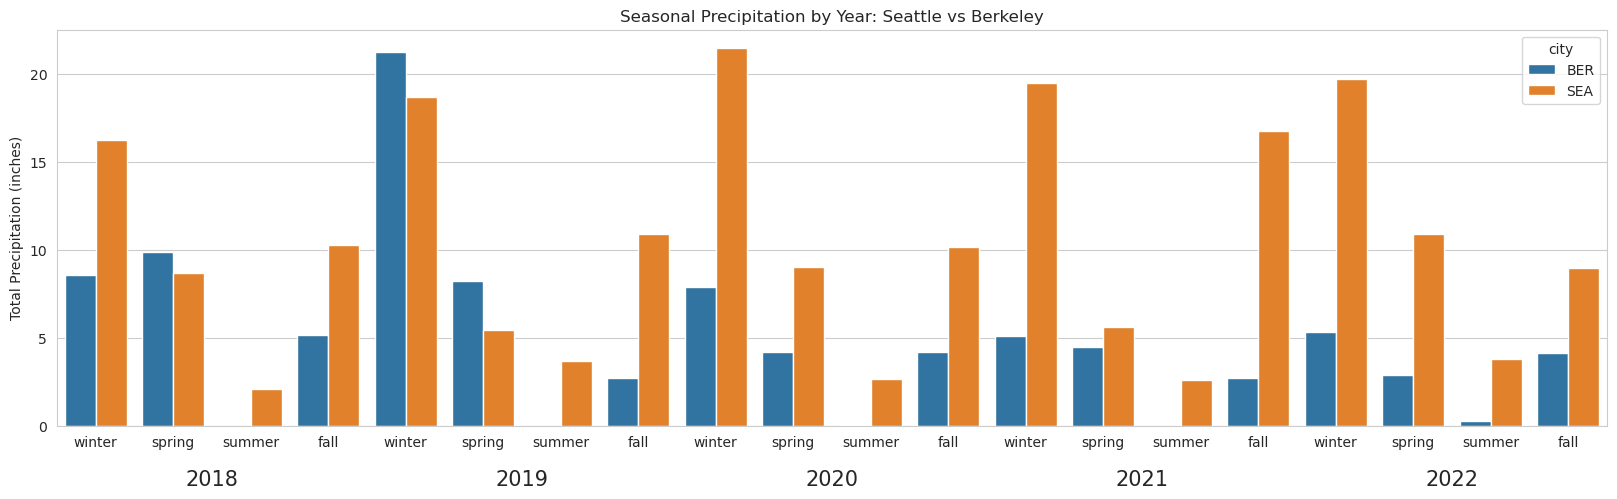

In [119]:
# Plot
plt.figure(figsize=(20, 6))

ax = sns.barplot( data=df_season, x='x_position', y='precipitation', hue='city')

# Season labels
ax.set_xticks(range(len(years) * 4))
ax.set_xticklabels(season_order * len(years))

# Year labels underneath each group of seasons
for i, year in enumerate(years):
    center = i * 4 + 1.5
    ax.text( center, -0.15, str(year), ha='center', transform=ax.get_xaxis_transform(), fontsize=15)

#Label
plt.xlabel('')
plt.ylabel('Total Precipitation (inches)')
plt.title('Seasonal Precipitation by Year: Seattle vs Berkeley')

plt.subplots_adjust(bottom=0.22)

plt.show()

Berkeley experienced unusually high total precipitation during winter 2019, exceeding Seattle during that season. This was an exceptional period compared with most other years, when Seattle generally received more precipitation than Berkeley.

#### More information related to this unusual event

Berkeley experienced unusually high precipitation during the 2018–2019 winter. Northern California was affected by a series of Pacific storms and atmospheric rivers, including a moderate-to-strong atmospheric river in January and another major event in mid-February. These systems transported large amounts of moisture from the Pacific Ocean into California, producing heavy rainfall across the Bay Area.

https://news.berkeley.edu/2019/01/18/this-weeks-rains-pushed-precipitation-above-average-but-average-isnt-enough/

The broader atmospheric pattern also contributed to the wet winter. A weak El Niño developed during this period, while changes in the Pacific jet stream helped direct moisture-rich storms toward California. Additionally, shorter-term atmospheric patterns and repeated atmospheric river events were important drivers.

https://www.noaa.gov/news/us-records-wettest-winter-capped-by-cooler-wetter-february-2019

Overall, the repeated storms help explain why Berkeley had exceptionally high precipitation during this period compared with the other years in the dataset. NOAA reported that much of the western United States experienced above-average precipitation during the December 2018–February 2019 winter.

## Analysis

### Perfrom a statistical test for differences in the mean precipitation each month between the cities

$$H_0: \mu_{\text{Seattle, January}} = \mu_{\text{Berkeley, January}}$$
$$H_a: \mu_{\text{Seattle, January}} \neq \mu_{\text{Berkeley, January}}$$

$$\vdots$$

$$H_0: \mu_{\text{Seattle, December}} = \mu_{\text{Berkeley, December}}$$
$$H_a: \mu_{\text{Seattle, December}} \neq \mu_{\text{Berkeley, December}}$$

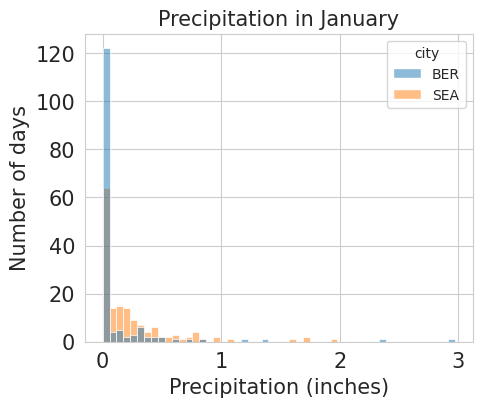

In [120]:
plt.figure(figsize = (5,4))

sns.histplot(data = df.loc[df['month'] == 1], x = 'precipitation', hue = 'city')

plt.xlabel('Precipitation (inches)', fontsize = 15)
plt.ylabel('Number of days', fontsize = 15)
plt.title('Precipitation in January', fontsize = 15)

plt.tick_params(labelsize = 15)

plt.show()

Use t test as an approximate test

In [121]:
from scipy import stats

In [122]:
significance_level = 0.05
significantly_different = np.zeros(12)

# Perform t-test for each month
for month in range(1, 13):
    # Get precipitation data for Seattle and Berkeley for the current month
    sea_data = df.loc[(df['city'] == 'SEA') & (df['month'] == month), 'precipitation']
    ber_data = df.loc[(df['city'] == 'BER') & (df['month'] == month), 'precipitation']

    t_statistic, p_value = stats.ttest_ind(sea_data, ber_data, equal_var = False)

    if p_value < significance_level:
        significantly_different[month - 1] = 1
        
    print(f"Month {month}:")
    print(f"  t-statistic = {t_statistic:.2f}")
    print(f"  p-value t test = {p_value:.3f}")
    print("-" * 20)

Month 1:
  t-statistic = 3.03
  p-value t test = 0.003
--------------------
Month 2:
  t-statistic = 2.45
  p-value t test = 0.015
--------------------
Month 3:
  t-statistic = -1.08
  p-value t test = 0.279
--------------------
Month 4:
  t-statistic = 1.89
  p-value t test = 0.059
--------------------
Month 5:
  t-statistic = 3.02
  p-value t test = 0.003
--------------------
Month 6:
  t-statistic = 5.15
  p-value t test = 0.000
--------------------
Month 7:
  t-statistic = 3.03
  p-value t test = 0.003
--------------------
Month 8:
  t-statistic = 3.97
  p-value t test = 0.000
--------------------
Month 9:
  t-statistic = 4.69
  p-value t test = 0.000
--------------------
Month 10:
  t-statistic = 3.84
  p-value t test = 0.000
--------------------
Month 11:
  t-statistic = 4.32
  p-value t test = 0.000
--------------------
Month 12:
  t-statistic = 3.14
  p-value t test = 0.002
--------------------


Plot the mean precipitation each month with a star for significant differences

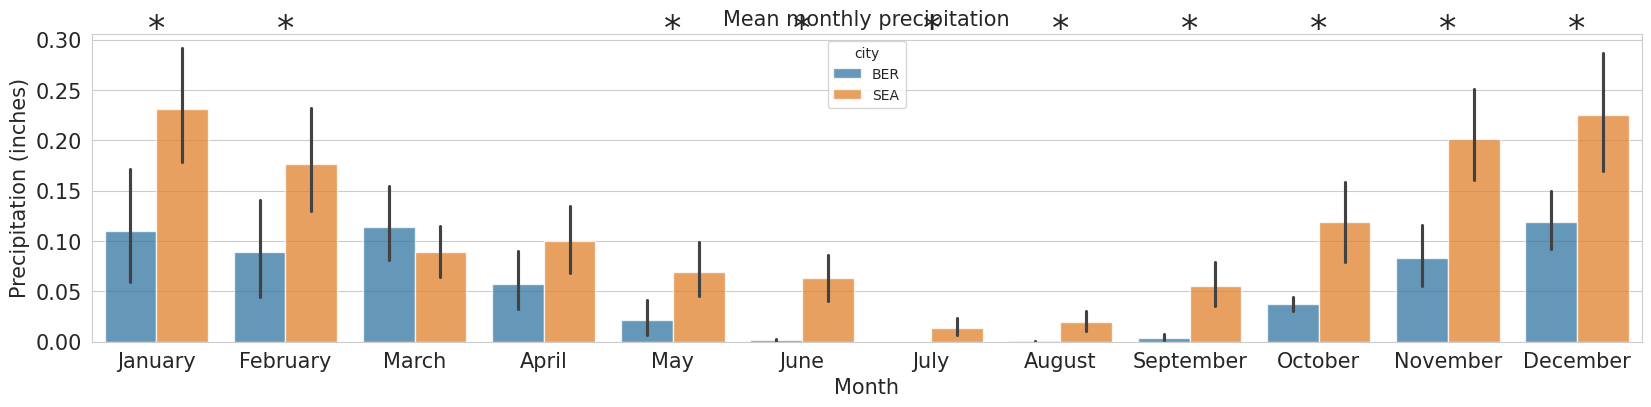

In [123]:
plt.figure(figsize =(20,4))

sns.barplot(data = df, x = 'month', y = 'precipitation', hue = 'city', alpha = 0.75)

plt.xlabel('Month', fontsize = 15)
plt.ylabel('Precipitation (inches)', fontsize = 15)
plt.title('Mean monthly precipitation', fontsize = 15)

plt.xticks(ticks = range(12), labels = month_names)
plt.tick_params(labelsize = 15)

# Add stars for significantly different months
for month in range(12):
    if significantly_different[month] == 1:

        # Add a star
        plt.text(month, 0.3, '*', ha = 'center', fontsize = 25)


plt.show()

At the 0.05 significance level, mean precipitation differs significantly between Seattle and Berkeley in every month except March and April.

### Perform a statistical test for differences in seasonal precipitation between the cities


$$H_0: \mu_{\text{Seattle, season}} = \mu_{\text{Berkeley, season}}$$

$$H_a: \mu_{\text{Seattle, season}} \neq \mu_{\text{Berkeley, season}}$$



In [124]:
# Perform paired t-test for each season
from scipy import stats

significance_level = 0.05
significantly_different_season = {}

for season in season_order:
    # Put Seattle and Berkeley seasonal totals side by side by year
    season_data = (
        df_season[df_season['season'] == season]
        .pivot(
            index='year',
            columns='city',
            values='precipitation'
        )
        .dropna()
    )

    # Paired t-test
    t_statistic, p_value = stats.ttest_rel(season_data['SEA'], season_data['BER'])
    significantly_different_season[season] = (p_value < significance_level)

    print(f"{season.capitalize()}:")
    print(f"  Seattle mean = {season_data['SEA'].mean():.2f} inches")
    print(f"  Berkeley mean = {season_data['BER'].mean():.2f} inches")
    print(f"  t-statistic = {t_statistic:.2f}")
    print(f"  p-value = {p_value:.3f}")
    print("-" * 30)

Winter:
  Seattle mean = 19.10 inches
  Berkeley mean = 9.62 inches
  t-statistic = 2.90
  p-value = 0.044
------------------------------
Spring:
  Seattle mean = 7.92 inches
  Berkeley mean = 5.92 inches
  t-statistic = 1.01
  p-value = 0.369
------------------------------
Summer:
  Seattle mean = 2.95 inches
  Berkeley mean = 0.06 inches
  t-statistic = 9.41
  p-value = 0.001
------------------------------
Fall:
  Seattle mean = 11.40 inches
  Berkeley mean = 3.77 inches
  t-statistic = 4.47
  p-value = 0.011
------------------------------


Seattle receives significantly more precipitation than Berkeley in winter, summer, and fall. The difference is especially large in summer, when Berkeley receives almost no precipitation. Spring is the only season where the difference is not statistically significant at the 0.05 level.

## Conclusion

Overall, the analysis shows that Seattle receives more precipitation than Berkeley. From 2018 through 2022, Seattle had an average daily precipitation of approximately 0.113 inches, compared with 0.053 inches in Berkeley.

The monthly analysis also supports this result. Mean precipitation was significantly different between the two cities in every month except March and April at the 0.05 significance level.

The seasonal analysis shows an even clearer pattern. Seattle received significantly more precipitation than Berkeley during winter, summer, and fall. The largest difference occurred during summer, when Seattle averaged 2.95 inches of precipitation compared with only 0.06 inches in Berkeley. Spring was the only season where the difference was not statistically significant.

Although Berkeley occasionally experienced unusually wet periods, such as winter 2019, these events were exceptions to the overall pattern. Therefore, based on the daily averages, monthly comparisons, and seasonal statistical tests, the results support the conclusion that **it rains more in Seattle than in Berkeley**.